В цьому наборі завдань закріпимо те, що було на лекції з Computer Vision.

# Computer Vision with PyTorch Excercises


## 1. Наведіть 3 галузі промисловості, де комп'ютерний зір використовується сьогодні (можна згадати з лекції, або провести міні-рісерч).

1. Аграрна промисловість: моніторинг стану посівів, автоматизація збору врожаю.
2. Автомобільна промисловість: автопілоти, безпека.
3. Медична промисловість: моніторинг стану здоров'я, діагностика знімки.

## 2. Виділіть 20 хвилин аби ознайомитись та переглянути сайт [CNN Explainer](https://poloclub.github.io/cnn-explainer/).

* Завантажте власне будь-яке зображення за допомогою кнопки Upload" на сайті та подивіться, що відбувається на кожному шарі CNN, коли ваше зображення проходить через нього.

Напишіть 3 пункти, що ви дізнались після цієї вправи?

1. На перших шарах (conv1) чітко видно контури та лінії завантаженого зображення.
2. Шар MaxPooling суттєво зменшує фізичний розмір картинки (вдвічі після кожного застосування).
3. Після шару ReLU все неважливе або фонове забарвлюється в суцільний чорний колір (перетворюється на нуль).

## 3. Завантажте навчальні та тестові набори даних [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST).

MNIST - базовий набір даних для задач Computer Vision. Часто використовується для навчання.

- Виведіть, скільки елементів в кожному наборі.
- Покажіть формат (розмірності) кожної картинки.
- Виведіть, які класи представлені в цьому наборі даних.

In [ ]:
import torch
from torch import nn
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import random
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

device_gpu = torch.device("mps")
device_cpu = torch.device("cpu")

In [16]:
train_data = datasets.MNIST(
    root="/Users/myko/ML/ml_course/module_4_nlp_and_deep_learning/dataframes/mnist",
    train=True,
    download=True,
    transform=ToTensor(),
)

test_data = datasets.MNIST(
    root="/Users/myko/ML/ml_course/module_4_nlp_and_deep_learning/dataframes/mnist",
    train=False,
    download=True,
    transform=ToTensor(),
)

In [ ]:
print(f"Train samples: {len(train_data.data)}")
print(f"Train labels: {len(train_data.targets)}")
print(f"Test samples: {len(test_data.data)}")
print(f"Test labels: {len(test_data.targets)}")

Train samples: 60000
Train labels: 60000
Test samples: 10000
Test labels: 10000


In [18]:
image, label = train_data[0]
print(f"Image shape: {image.shape}")
print(f"Label: {label}")

Image shape: torch.Size([1, 28, 28])
Label: 5


In [19]:
class_names = train_data.classes
print(f"Class names: {class_names}")

Class names: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


## 4. Візуалізуйте щонайменше 5 різних зразків з навчального набору даних MNIST.

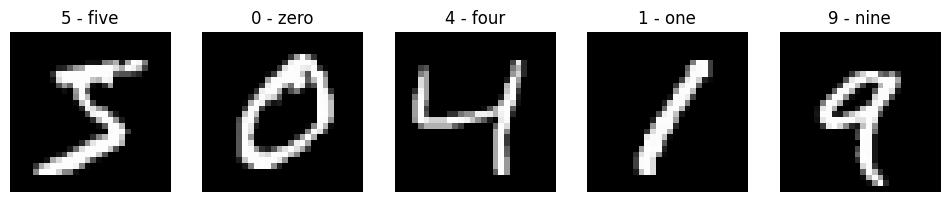

In [20]:
fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for i in range(5):
    image, label = train_data[i]
    axes[i].imshow(image.squeeze(), cmap="gray")
    axes[i].set_title(class_names[label])
    axes[i].axis("off")
plt.show()

## 5. Перетворіть навчальні та тестові набори даних MNIST у data loaders за допомогою `torch.utils.data.DataLoader`, встановіть `batch_size=32`.
- Покажіть, яку форму даних вертають дата лоадери.

In [21]:
train_dl = DataLoader(train_data, batch_size=32, shuffle=True)
test_dl = DataLoader(test_data, batch_size=32)
train_features, train_labels = next(iter(train_dl))

print(f"Train dataloader: {len(train_dl)} batches")
print(f"Test dataloader: {len(test_dl)} batches")
print(f"Train features shape: {train_features.shape}")
print(f"Train labels shape: {train_labels.shape}")

Train dataloader: 1875 batches
Test dataloader: 313 batches
Train features shape: torch.Size([32, 1, 28, 28])
Train labels shape: torch.Size([32])


## 6. Відтворіть `ModelV2`, яку ми розглядали на лекції
Це до слова та сама модель з [сайту CNN Explainer](https://poloclub.github.io/cnn-explainer/), також відома як TinyVGG і вона здатна навчатися на наборі даних MNIST.

Напишіть клас моделі.

In [22]:
class MNISTModelLV2(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(
                in_channels=input_shape,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1,
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1,
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1,
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1,
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units * 7 * 7, out_features=output_shape),
        )

    def forward(self, x):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.classifier(x)
        return x

## 7. Навчіть модель, яку ви побудували в попередній вправі, протягом 5 епох на CPU та GPU і подивіться, скільки часу це займе в кожному з варіантів.

In [23]:
from timeit import default_timer as timer


def train_model_on_device(target_device):
    torch.manual_seed(42)
    model = MNISTModelLV2(
        input_shape=1, hidden_units=10, output_shape=len(class_names)
    ).to(target_device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

    train_time_start_model = timer()

    train_loss = []
    train_acc = []
    test_loss = []
    test_acc = []

    for epoch in range(5):
        model.train()
        running_train_loss, running_train_acc = 0, 0
        for xb, yb in train_dl:
            xb, yb = xb.to(target_device), yb.to(target_device)
            y_pred = model(xb)
            loss = criterion(y_pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()
            running_train_acc += (y_pred.argmax(1) == yb).sum().item() / len(yb) * 100
        epoch_train_loss = running_train_loss / len(train_dl)
        epoch_train_acc = running_train_acc / len(train_dl)
        train_loss.append(epoch_train_loss)
        train_acc.append(epoch_train_acc)

        model.eval()
        running_test_loss, running_test_acc = 0, 0
        with torch.inference_mode():
            for xb, yb in test_dl:
                xb, yb = xb.to(target_device), yb.to(target_device)
                test_pred = model(xb)
                running_test_loss += criterion(test_pred, yb).item()
                running_test_acc += (
                    (test_pred.argmax(1) == yb).sum().item() / len(yb) * 100
                )

            epoch_test_loss = running_test_loss / len(test_dl)
            epoch_test_acc = running_test_acc / len(test_dl)
            test_loss.append(epoch_test_loss)
            test_acc.append(epoch_test_acc)

        print(
            f"Epoch {epoch + 1}: train loss: {train_loss[-1]:.3f}, train acc: {train_acc[-1]:.2f}, test loss: {test_loss[-1]:.3f}, test acc: {test_acc[-1]:.2f}"
        )

    train_time_end_model = timer()
    print(
        f"Model training time in {target_device}: {train_time_end_model - train_time_start_model:.2f} seconds"
    )
    return model


print("Training model on CPU")
train_model_on_device(device_cpu)
print("\nTraining model on GPU")
model = train_model_on_device(device_gpu)

Training model on CPU
Epoch 1: train loss: 0.262, train acc: 91.37, test loss: 0.069, test acc: 97.77
Epoch 2: train loss: 0.069, train acc: 97.83, test loss: 0.043, test acc: 98.61
Epoch 3: train loss: 0.054, train acc: 98.33, test loss: 0.041, test acc: 98.60
Epoch 4: train loss: 0.045, train acc: 98.55, test loss: 0.037, test acc: 98.74
Epoch 5: train loss: 0.039, train acc: 98.75, test loss: 0.032, test acc: 98.97
Model training time in cpu: 100.69 seconds

Training model on GPU
Epoch 1: train loss: 0.271, train acc: 91.15, test loss: 0.077, test acc: 97.41
Epoch 2: train loss: 0.068, train acc: 97.90, test loss: 0.044, test acc: 98.53
Epoch 3: train loss: 0.054, train acc: 98.33, test loss: 0.042, test acc: 98.56
Epoch 4: train loss: 0.044, train acc: 98.56, test loss: 0.040, test acc: 98.77
Epoch 5: train loss: 0.039, train acc: 98.74, test loss: 0.037, test acc: 98.77
Model training time in mps: 25.13 seconds


## 8. Зробіть прогнози за допомогою вашої навченої моделі та візуалізуйте принаймні 5 з них, порівнюючи прогноз з цільовою міткою.

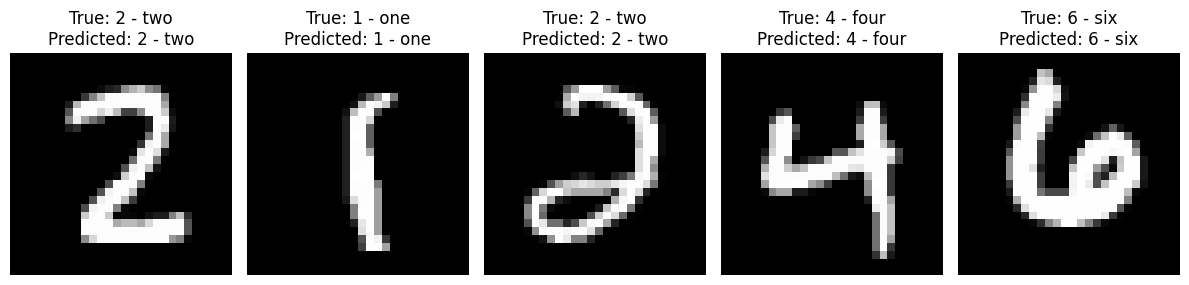

In [24]:
model.eval()

test_pred_list = []
test_labels_list = []

with torch.inference_mode():
    for xb, yb in test_dl:
        xb = xb.to(device_gpu)
        logits = model(xb)
        pred_label = logits.argmax(dim=1)
        test_pred_list.append(pred_label.cpu())
        test_labels_list.append(yb.cpu())

test_pred_list = torch.cat(test_pred_list)
test_labels_list = torch.cat(test_labels_list)

random.seed(42)
random_indices = random.sample(range(len(test_data)), k=5)
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i, idx in enumerate(random_indices):
    image, _ = test_data[idx]
    pred_label = test_pred_list[idx].item()
    true_label = test_labels_list[idx].item()
    pred_name = class_names[pred_label]
    true_name = class_names[true_label]
    axes[i].imshow(image.squeeze(), cmap="gray")
    title = f"True: {true_name}\nPredicted: {pred_name}"
    axes[i].set_title(title)
    axes[i].axis("off")
plt.tight_layout()
plt.show()

## 9. Побудуйте матрицю плутанини, порівнюючи передбачення вашої моделі з істинними мітками.

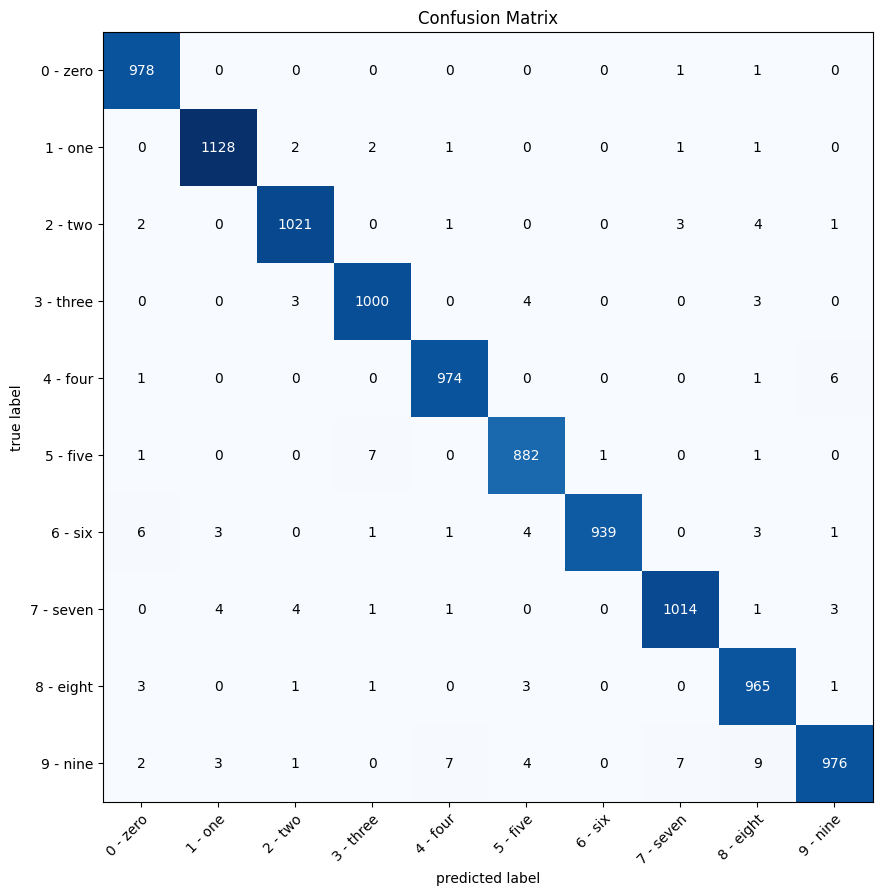

In [25]:
conf_matrix = ConfusionMatrix(task="multiclass", num_classes=len(class_names))
conf_tensor = conf_matrix(preds=test_pred_list, target=test_labels_list)
fig, ax = plot_confusion_matrix(
    conf_mat=conf_tensor.numpy(), class_names=class_names, figsize=(10, 10)
)
plt.title("Confusion Matrix")
plt.show()

## 10. Виведіть принаймні 9 прикладів, де модель помиляється, разом з тим, якою мала бути мітка зображення.
* Після візуалізації цих прогнозів, як ви думаєте, це більше помилка моделювання чи помилка даних?
* Тобто, чи може модель працювати краще, чи мітки даних занадто близькі одна до одної, що навіть людина не може чітко розрізнити що це за цифра?

In [26]:
error_indices = torch.where(test_pred_list != test_labels_list)[0].tolist()
print(f"Number of errors: {len(error_indices)}")

Number of errors: 123


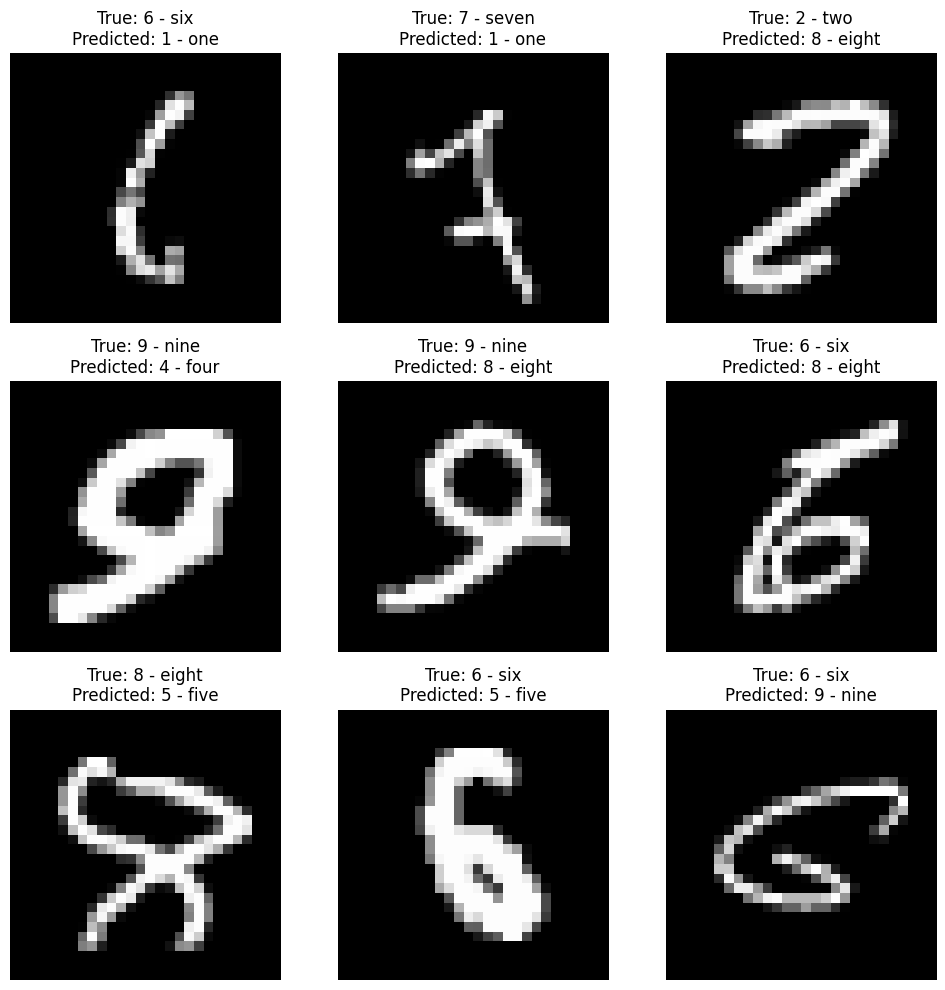

In [27]:
random.seed(42)
plt.figure(figsize=(10, 10))
nrows, ncols = 3, 3
random_error_samples = random.sample(error_indices, k=9)
for i, idx in enumerate(random_error_samples):
    image, _ = test_data[idx]
    pred_label = test_pred_list[idx].item()
    true_label = test_labels_list[idx].item()
    pred_name = class_names[pred_label]
    true_name = class_names[true_label]
    plt.subplot(nrows, ncols, i + 1)
    plt.imshow(image.squeeze(), cmap="gray")
    title = f"True: {true_name}\nPredicted: {pred_name}"
    plt.title(title)
    plt.axis("off")
plt.tight_layout()
plt.show()

Це однозначно помилка даних - нечіткість або аномальність самих зображень. Сама модель я вважаю працює чудово, адже її загальна точність становить близько 98%. Модель не винна в тому, що люди пишуть цифри дуже неохайно або дивно.
Мітки та стиль написання дійсно занадто близькі одна до одної, і навіть людині важко розрізнити деякі з них.

## 11. Створіть випадковий тензор форми `[1, 3, 64, 64]` і пропустіть його через шар `nn.Conv2d()` з різними налаштуваннями гіперпараметрів (ви можете вибрати будь-які налаштування), що ви помічаєте, якщо параметр `kernel_size` збільшується або зменшується?

In [28]:
torch.manual_seed(42)
input_tensor = torch.randn(1, 3, 64, 64)
print(f"Input tensor shape: {input_tensor.shape}")

conv_small = nn.Conv2d(in_channels=3, out_channels=10, kernel_size=3)
conv_medium = nn.Conv2d(in_channels=3, out_channels=10, kernel_size=5)
conv_large = nn.Conv2d(in_channels=3, out_channels=10, kernel_size=11)

output_small = conv_small(input_tensor)
output_medium = conv_medium(input_tensor)
output_large = conv_large(input_tensor)

print(f"Output shape for small kernel: {output_small.shape}")
print(f"Output shape for medium kernel: {output_medium.shape}")
print(f"Output shape for large kernel: {output_large.shape}")

Input tensor shape: torch.Size([1, 3, 64, 64])
Output shape for small kernel: torch.Size([1, 10, 62, 62])
Output shape for medium kernel: torch.Size([1, 10, 60, 60])
Output shape for large kernel: torch.Size([1, 10, 54, 54])


Коли параметр kernel_size збільшується, висота та ширина вихідного тензора зменшується. Велике ядро згортки займає більше місця на зображенні під час сканування. Оскільки за замовчуванням padding=0 (шар не додає рамку з нулів по краях), велике квадратне вікно не може вийти за межі картинки і має менше доступних кроків для зсуву. Через це ми сильніше "втрачаємо" краї зображення, і вихідна матриця стискається сильніше.